# Dynamic Pressure on Ascent

Dynamic pressure $q = \frac{1}{2} \rho \, v^2$

- **Velocity** from HR-derived data (`vel_mag_m_s`, 500 Hz)
- **Air density** $\rho$ from LR barometric pressure and temperature via the ideal gas law:
  $\rho = \frac{P}{R_{specific} \cdot T}$
- $R_{specific} = 287.058\;J/(kg \cdot K)$
- Ascent phase: liftoff ($t = 0$) to drogue deployment ($t \approx 38.6\;\text{s}$)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from path_config import default_lr_csv, default_analysis_dir, default_hr_csv

# ── Load HR-derived data (500 Hz) ──────────────────────────────────
hr_csv = default_hr_csv()
hr_dir = default_analysis_dir(hr_csv)
hr = pd.read_csv(hr_dir / "hr_derived.csv")

# ── Load LR data (50 Hz) ──────────────────────────────────────────
lr = pd.read_csv(default_lr_csv())

print(f"HR rows: {len(hr):,}  |  LR rows: {len(lr):,}")
print(f"HR time range: {hr['time_s'].iloc[0]:.3f} – {hr['time_s'].iloc[-1]:.3f} s")
print(f"LR time range: {lr['Flight_Time_(s)'].iloc[0]:.3f} – {lr['Flight_Time_(s)'].iloc[-1]:.3f} s")

HR rows: 168,680  |  LR rows: 16,860
HR time range: -2.026 – 335.332 s
LR time range: -1.940 – 335.240 s


In [2]:
# ── Filter to ascent phase (t = 0 to drogue at ~38.6 s) ───────────
DROGUE_T = 38.6  # seconds

hr_asc = hr[(hr["time_s"] >= 0) & (hr["time_s"] <= DROGUE_T)].copy()
lr_asc = lr[(lr["Flight_Time_(s)"] >= 0) & (lr["Flight_Time_(s)"] <= DROGUE_T)].copy()

# ── Interpolate LR pressure & temperature onto HR time grid ───────
# Pressure: atm → Pa  (1 atm = 101325 Pa)
# Temperature: °F → K
lr_t = lr_asc["Flight_Time_(s)"].values
lr_press_pa = lr_asc["Baro_Press_(atm)"].values * 101_325.0
lr_temp_k = (lr_asc["Temperature_(F)"].values - 32) * 5 / 9 + 273.15

f_press = interp1d(lr_t, lr_press_pa, kind="linear", fill_value="extrapolate")
f_temp = interp1d(lr_t, lr_temp_k, kind="linear", fill_value="extrapolate")

hr_asc["press_pa"] = f_press(hr_asc["time_s"].values)
hr_asc["temp_k"] = f_temp(hr_asc["time_s"].values)

# ── Air density via ideal gas law ─────────────────────────────────
R_SPECIFIC = 287.058  # J/(kg·K) for dry air
hr_asc["rho_kg_m3"] = hr_asc["press_pa"] / (R_SPECIFIC * hr_asc["temp_k"])

# ── Dynamic pressure ─────────────────────────────────────────────
hr_asc["q_pa"] = 0.5 * hr_asc["rho_kg_m3"] * hr_asc["vel_mag_m_s"] ** 2
hr_asc["q_psf"] = hr_asc["q_pa"] * 0.020885  # Pa → psf

# ── Speed of sound & Mach number ─────────────────────────────────
GAMMA = 1.4
hr_asc["a_m_s"] = np.sqrt(GAMMA * R_SPECIFIC * hr_asc["temp_k"])
hr_asc["mach"] = hr_asc["vel_mag_m_s"] / hr_asc["a_m_s"]

# ── Interpolate altitude onto HR time for later plots ─────────────
lr_alt_ft = lr_asc["Baro_Altitude_AGL_(feet)"].values
f_alt = interp1d(lr_t, lr_alt_ft, kind="linear", fill_value="extrapolate")
hr_asc["alt_agl_ft"] = f_alt(hr_asc["time_s"].values)

# ── Max-Q summary ────────────────────────────────────────────────
idx_maxq = hr_asc["q_pa"].idxmax()
maxq = hr_asc.loc[idx_maxq]
print(f"Max-Q: {maxq['q_pa']:,.0f} Pa  ({maxq['q_psf']:,.1f} psf)")
print(f"  at t = {maxq['time_s']:.3f} s,  Mach {maxq['mach']:.2f}")
print(f"  velocity = {maxq['vel_mag_m_s']:.1f} m/s,  altitude = {maxq['alt_agl_ft']:,.0f} ft AGL")
print(f"  air density = {maxq['rho_kg_m3']:.4f} kg/m³")

Max-Q: 170,508 Pa  (3,561.0 psf)
  at t = 3.280 s,  Mach 1.71
  velocity = 599.8 m/s,  altitude = 3,476 ft AGL
  air density = 0.9478 kg/m³


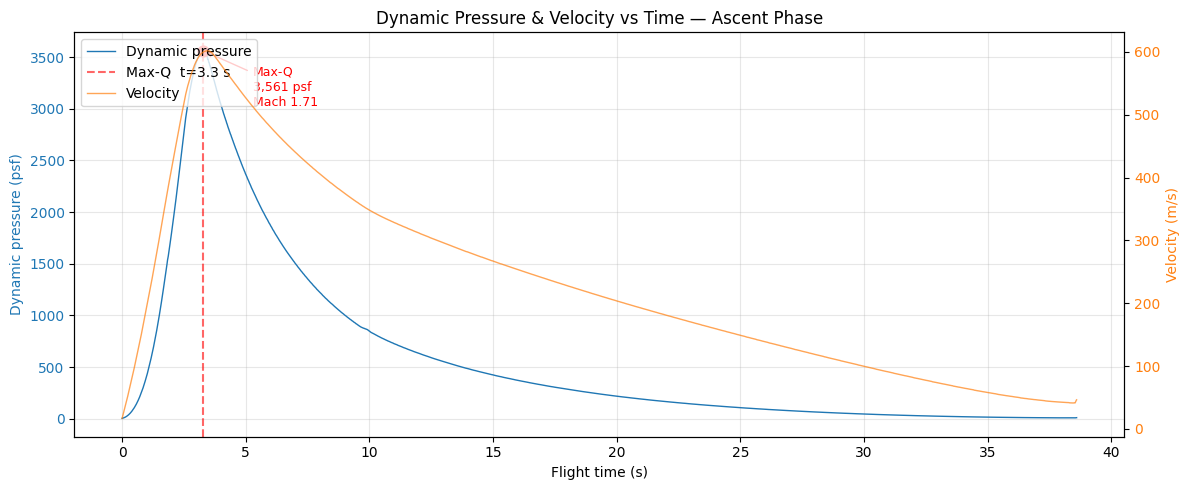

In [3]:
# ── Plot: Dynamic Pressure & Velocity vs Time ────────────────────
fig, ax1 = plt.subplots(figsize=(12, 5))

color_q = "#1f77b4"
color_v = "#ff7f0e"

ax1.plot(hr_asc["time_s"], hr_asc["q_psf"], color=color_q, linewidth=1, label="Dynamic pressure")
ax1.set_xlabel("Flight time (s)")
ax1.set_ylabel("Dynamic pressure (psf)", color=color_q)
ax1.tick_params(axis="y", labelcolor=color_q)

# Mark Max-Q
ax1.axvline(maxq["time_s"], color="red", linestyle="--", alpha=0.6, label=f"Max-Q  t={maxq['time_s']:.1f} s")
ax1.scatter([maxq["time_s"]], [maxq["q_psf"]], color="red", zorder=5, s=60)
ax1.annotate(
    f"Max-Q\n{maxq['q_psf']:,.0f} psf\nMach {maxq['mach']:.2f}",
    xy=(maxq["time_s"], maxq["q_psf"]),
    xytext=(maxq["time_s"] + 2, maxq["q_psf"] * 0.85),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="red"),
    color="red",
)

ax2 = ax1.twinx()
ax2.plot(hr_asc["time_s"], hr_asc["vel_mag_m_s"], color=color_v, linewidth=1, alpha=0.7, label="Velocity")
ax2.set_ylabel("Velocity (m/s)", color=color_v)
ax2.tick_params(axis="y", labelcolor=color_v)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("Dynamic Pressure & Velocity vs Time — Ascent Phase")
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

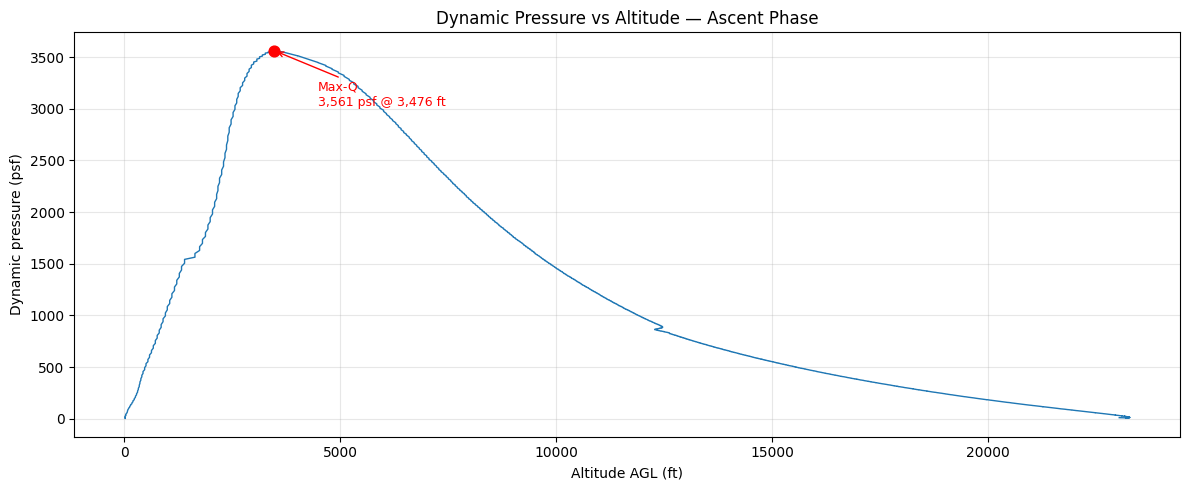

In [4]:
# ── Plot: Dynamic Pressure vs Altitude ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(hr_asc["alt_agl_ft"], hr_asc["q_psf"], color=color_q, linewidth=1)
ax.scatter([maxq["alt_agl_ft"]], [maxq["q_psf"]], color="red", zorder=5, s=60)
ax.annotate(
    f"Max-Q\n{maxq['q_psf']:,.0f} psf @ {maxq['alt_agl_ft']:,.0f} ft",
    xy=(maxq["alt_agl_ft"], maxq["q_psf"]),
    xytext=(maxq["alt_agl_ft"] + 1000, maxq["q_psf"] * 0.85),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="red"),
    color="red",
)

ax.set_xlabel("Altitude AGL (ft)")
ax.set_ylabel("Dynamic pressure (psf)")
ax.set_title("Dynamic Pressure vs Altitude — Ascent Phase")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

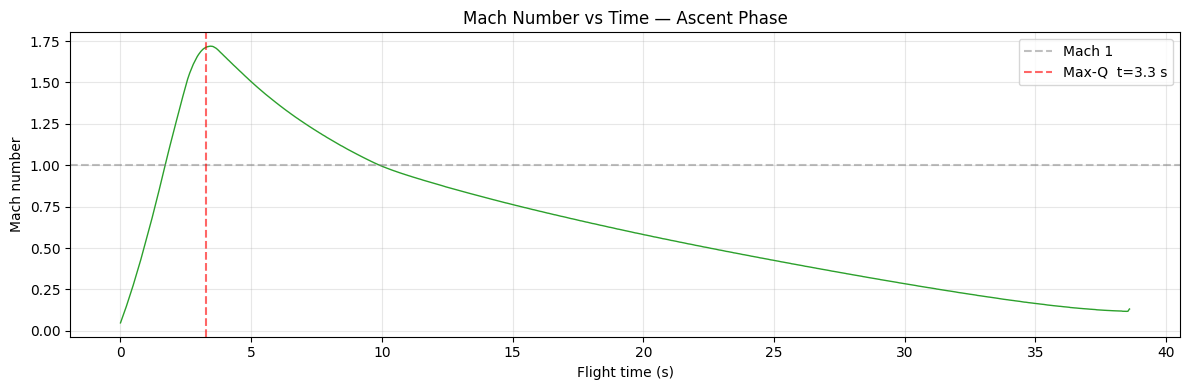

In [ ]:
# ── Plot: Mach Number vs Time ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(hr_asc["time_s"], hr_asc["mach"], color="#2ca02c", linewidth=1)
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="Mach 1")
ax.axvline(maxq["time_s"], color="red", linestyle="--", alpha=0.6, label=f"Max-Q  t={maxq['time_s']:.1f} s")

ax.set_xlabel("Flight time (s)")
ax.set_ylabel("Mach number")
ax.set_title("Mach Number vs Time — Ascent Phase")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()